<a href="https://colab.research.google.com/github/AmorimSilva/Codigos-Gerais/blob/main/shapefiles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/ipeaGIT/geobr?tab=readme-ov-file

In [82]:
!pip install geopandas==1.1.0
print('ok!')
!pip install matplotlib==3.10.0
print('ok!')
!pip install numpy==2.0.2
print('ok!')
!pip install pandas==2.2.2
print('ok!')
!pip install geobr
print('ok!')
!pip install geopandas
print('ok!')

ok!
ok!
ok!
ok!
ok!
ok!


In [83]:
import geobr
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [86]:
# Bioma Amazônia
todos_biomas = geobr.read_biomes(year=2019)
amazonia = todos_biomas[todos_biomas['name_biome'] == 'Amazônia']

# Terras Indígenas
terras_indigenas = geobr.read_indigenous_land()

# Unidades de Conservação
unidades_conservacao = geobr.read_conservation_units()

In [85]:
terras_indigenas_recortadas = gpd.clip(terras_indigenas, amazonia)
unidades_conservacao_recortadas = gpd.clip(unidades_conservacao, amazonia)

print(f"-> {len(terras_indigenas_recortadas)} Terras Indígenas recortadas para a Amazônia.")
print(f"-> {len(unidades_conservacao_recortadas)} Unidades de Conservação recortadas para a Amazônia.")

-> 330 Terras Indígenas recortadas para a Amazônia.
-> 298 Unidades de Conservação recortadas para a Amazônia.


In [87]:
# CRS
CRS_PROJETADO_EPSG = 5880

# Reprojeta todos os GeoDataFrames
amazonia_proj = amazonia.to_crs(epsg=CRS_PROJETADO_EPSG)
terras_indigenas_recortadas_proj = terras_indigenas_recortadas.to_crs(epsg=CRS_PROJETADO_EPSG)
unidades_conservacao_recortadas_proj = unidades_conservacao_recortadas.to_crs(epsg=CRS_PROJETADO_EPSG)

# área em metros quadrados e converte para hectares (1 ha = 10.000 m²)
area_ti_recortada_ha = terras_indigenas_recortadas_proj.geometry.area.sum() / 10000
area_uc_recortada_ha = unidades_conservacao_recortadas_proj.geometry.area.sum() / 10000
area_total_bioma_amazonia = amazonia_proj.geometry.area.sum() / 10000

# geometrias
areas_protegidas_combinadas = pd.concat([
    terras_indigenas_recortadas_proj[['geometry']],
    unidades_conservacao_recortadas_proj[['geometry']]
])
area_total_protegida_ha = areas_protegidas_combinadas.union_all().area / 10000

print("\n--- Resultados da Análise de Área  ---")
print(f"Área Total do Bioma Amazônia: {area_total_bioma_amazonia:,.2f} ha")
print("-" * 35)
print(f"Área coberta por Terras Indígenas: {area_ti_recortada_ha:,.2f} ha ({ (area_ti_recortada_ha/area_total_bioma_amazonia):.2%})")
print(f"Área coberta por Unidades de Conservação: {area_uc_recortada_ha:,.2f} ha ({ (area_uc_recortada_ha/area_total_bioma_amazonia):.2%})")
print("-" * 35)
print(f"Área Total Protegida (TIs + UCs, sem sobreposição): {area_total_protegida_ha:,.2f} ha")
print(f"PERCENTUAL TOTAL DA AMAZÔNIA SOB PROTEÇÃO: { (area_total_protegida_ha/area_total_bioma_amazonia):.2%}")


--- Resultados da Análise de Área  ---
Área Total do Bioma Amazônia: 426,162,253.84 ha
-----------------------------------
Área coberta por Terras Indígenas: 108,606,052.66 ha (25.48%)
Área coberta por Unidades de Conservação: 120,368,163.19 ha (28.24%)
-----------------------------------
Área Total Protegida (TIs + UCs, sem sobreposição): 215,353,923.65 ha
PERCENTUAL TOTAL DA AMAZÔNIA SOB PROTEÇÃO: 50.53%


/tmp/ipython-input-231440431.py:9: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipython-input-231440431.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


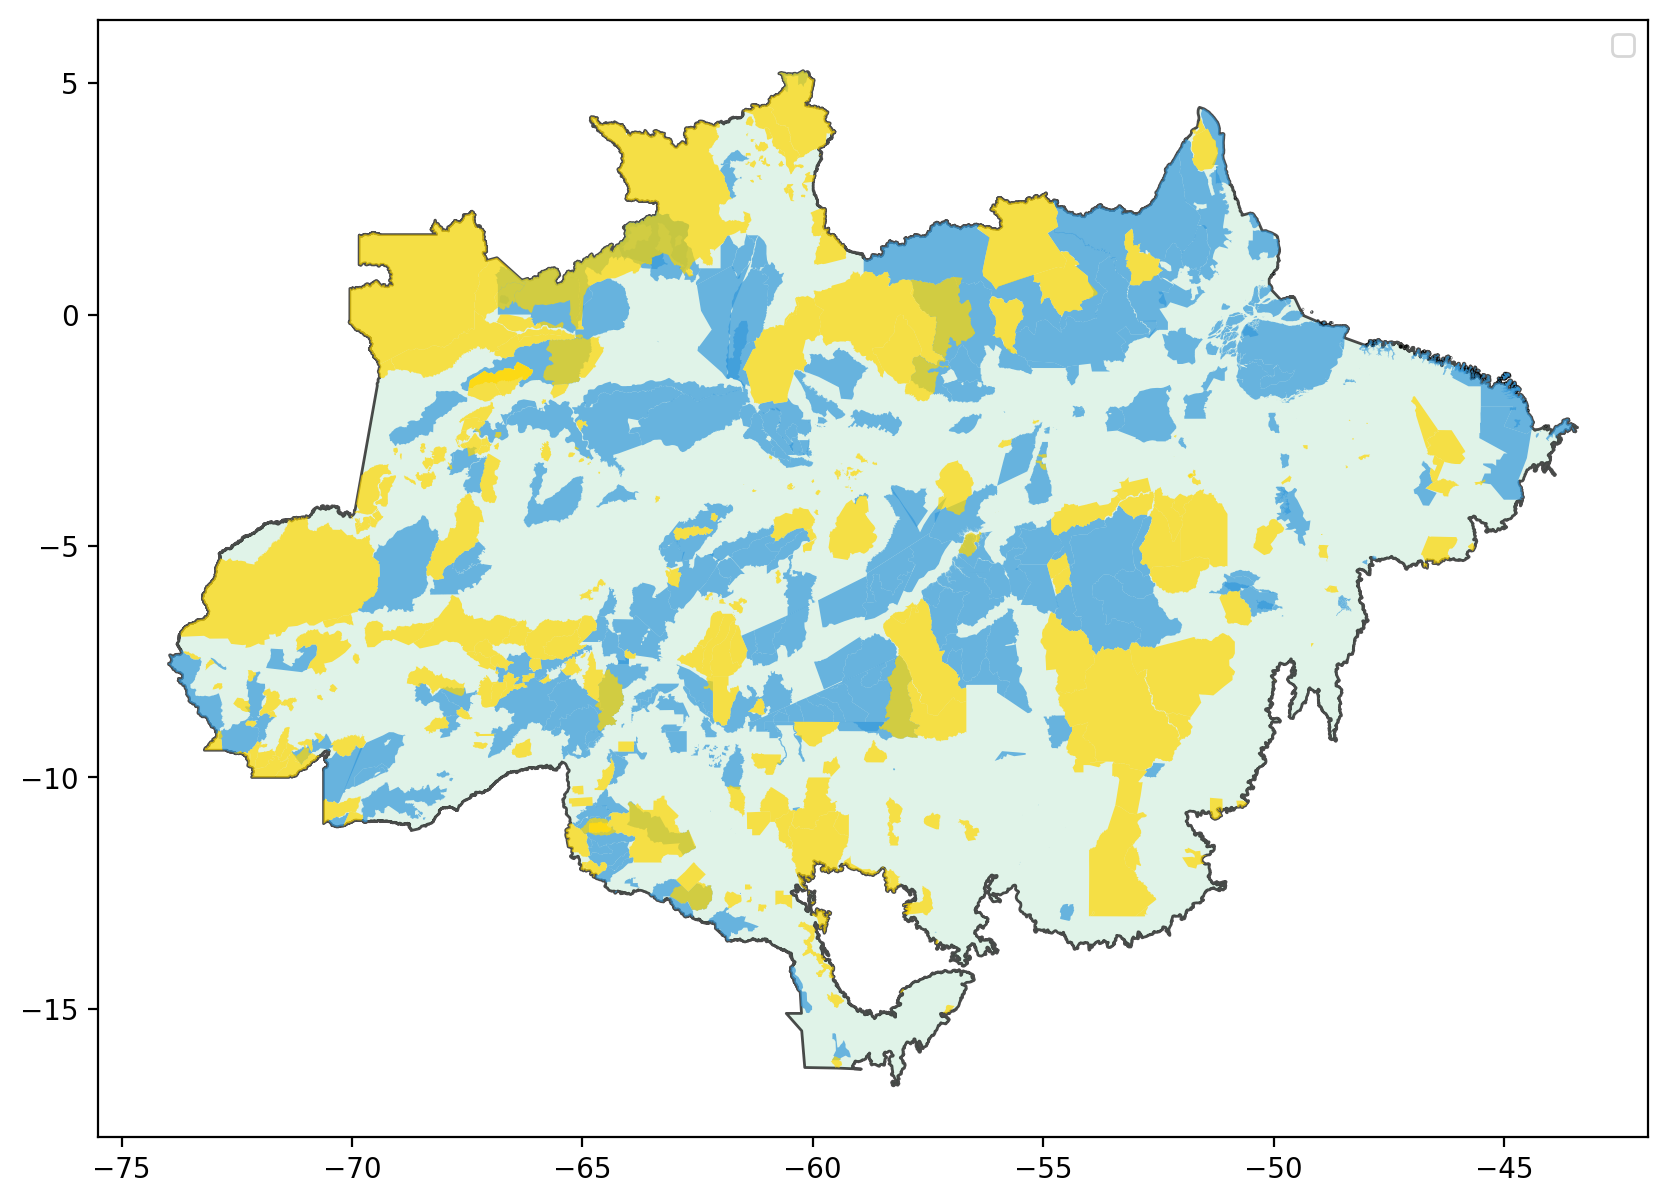

In [88]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=200)
AMAZONIA_COLOR = '#D4EFDF'
TI_COLOR = '#FFD700'
UC_COLOR = '#3498DB'
amazonia.plot(ax=ax, color=AMAZONIA_COLOR, edgecolor='black', alpha=0.7, label='Bioma Amazônia')
unidades_conservacao_recortadas.plot(ax=ax, color=UC_COLOR, alpha=0.7, label='Unidades de Conservação')
terras_indigenas_recortadas.plot(ax=ax, color=TI_COLOR, alpha=0.7, label='Terras Indígenas')
ax.axis('on')
ax.legend()
plt.savefig('mapa_areas_protegidas_amazonia.png', bbox_inches='tight')
plt.show()

In [89]:
os.makedirs('shp_terras_indigenas_corrigido', exist_ok=True)
os.makedirs('shp_unidades_conservacao', exist_ok=True)
os.makedirs('shp_bioma_amazonia', exist_ok=True)

####
ti_para_exportar_corrigido = terras_indigenas_recortadas.copy()
ti_para_exportar_corrigido['undadm_cod'] = ti_para_exportar_corrigido['undadm_cod'].astype(str)
ti_para_exportar_corrigido.to_file('shp_terras_indigenas_corrigido/terras_indigenas_corrigido.shp')
unidades_conservacao_recortadas.to_file('shp_unidades_conservacao/unidades_conservacao.shp', driver='ESRI Shapefile')
amazonia.to_file('shp_bioma_amazonia/bioma_amazonia.shp', driver='ESRI Shapefile')

/tmp/ipython-input-336455426.py:8: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  ti_para_exportar_corrigido.to_file('shp_terras_indigenas_corrigido/terras_indigenas_corrigido.shp')
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'code_terrai' to 'code_terra'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'abbrev_state' to 'abbrev_sta'
  ogr_write(
/tmp/ipython-input-336455426.py:9: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  unidades_conservacao_recortadas.to_file('shp_unidades_conservacao/unidades_conservacao.shp', driver='ESRI Shapefile')
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'code_conservation_unit' to 'code_conse'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/

In [66]:
!zip -r shapefiles_amazonia.zip shp_terras_indigenas_corrigido shp_unidades_conservacao shp_bioma_amazonia

  adding: shp_terras_indigenas_corrigido/ (stored 0%)
  adding: shp_terras_indigenas_corrigido/terras_indigenas_corrigido.dbf (deflated 95%)
  adding: shp_terras_indigenas_corrigido/terras_indigenas_corrigido.shp (deflated 18%)
  adding: shp_terras_indigenas_corrigido/terras_indigenas_corrigido.prj (deflated 17%)
  adding: shp_terras_indigenas_corrigido/terras_indigenas_corrigido.cpg (stored 0%)
  adding: shp_terras_indigenas_corrigido/terras_indigenas_corrigido.shx (deflated 28%)
  adding: shp_unidades_conservacao/ (stored 0%)
  adding: shp_unidades_conservacao/unidades_conservacao.cpg (stored 0%)
  adding: shp_unidades_conservacao/unidades_conservacao.shp (deflated 17%)
  adding: shp_unidades_conservacao/unidades_conservacao.shx (deflated 30%)
  adding: shp_unidades_conservacao/unidades_conservacao.dbf (deflated 95%)
  adding: shp_unidades_conservacao/unidades_conservacao.prj (deflated 17%)
  adding: shp_bioma_amazonia/ (stored 0%)
  adding: shp_bioma_amazonia/bioma_amazonia.shp (def

In [90]:
#Unir areas
df_ti = terras_indigenas_recortadas[['terrai_nom', 'geometry']].copy()
df_ti.rename(columns={'terrai_nom': 'nome'}, inplace=True)
df_ti['tipo'] = 'Terra Indígena'

df_uc = unidades_conservacao_recortadas[['name_conservation_unit', 'geometry']].copy()
df_uc.rename(columns={'name_conservation_unit': 'nome'}, inplace=True)
df_uc['tipo'] = 'Unidade de Conservação'

# Concatena os dois DataFrames
areas_protegidas_empilhadas = pd.concat([df_ti, df_uc], ignore_index=True)

print(f"\nUnião concluída! O novo GeoDataFrame 'areas_protegidas_empilhadas' tem {len(areas_protegidas_empilhadas)} polígonos.")
print("Ele contém uma coluna 'tipo' que diferencia 'Terra Indígena' de 'Unidade de Conservação'.")
areas_protegidas_empilhadas.head()


União concluída! O novo GeoDataFrame 'areas_protegidas_empilhadas' tem 628 polígonos.
Ele contém uma coluna 'tipo' que diferencia 'Terra Indígena' de 'Unidade de Conservação'.


,nome,geometry,tipo
0,Batovi,"POLYGON ((-53.90688 -12.8961, -53.9043 -12.892...",Terra Indígena
1,Pequizal do Naruvôtu,"POLYGON ((-52.79765 -13.00216, -52.90039 -13.0...",Terra Indígena
2,Portal do Encantado,"POLYGON ((-59.42375 -16.11747, -59.42196 -16.1...",Terra Indígena
3,Sararé,"POLYGON ((-59.55492 -14.69289, -59.53693 -14.6...",Terra Indígena
4,Paukalirajausu,"POLYGON ((-59.66823 -14.68992, -59.66654 -14.6...",Terra Indígena


In [91]:
os.makedirs('shp_bioma_amazonia', exist_ok=True)


In [71]:
#exportar shape das áreas para eu recortar a prec em outro script
output_dir = 'shp_areas_protegidas_empilhadas'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'areas_protegidas_empilhadas.shp')
areas_protegidas_empilhadas.to_file(output_path, driver='ESRI Shapefile')
zip_file_name = 'areas_protegidas_empilhadas.zip'
!zip -r {zip_file_name} {output_dir}

print(f"\nShapefile exportado para '{output_path}'")
print(f"Arquivo zip '{zip_file_name}' criado. Você pode baixá-lo agora.")

  adding: shp_areas_protegidas_empilhadas/ (stored 0%)
  adding: shp_areas_protegidas_empilhadas/areas_protegidas_empilhadas.cpg (stored 0%)
  adding: shp_areas_protegidas_empilhadas/areas_protegidas_empilhadas.dbf (deflated 93%)
  adding: shp_areas_protegidas_empilhadas/areas_protegidas_empilhadas.shx (deflated 29%)
  adding: shp_areas_protegidas_empilhadas/areas_protegidas_empilhadas.prj (deflated 17%)
  adding: shp_areas_protegidas_empilhadas/areas_protegidas_empilhadas.shp (deflated 17%)

Shapefile exportado para 'shp_areas_protegidas_empilhadas/areas_protegidas_empilhadas.shp'
Arquivo zip 'areas_protegidas_empilhadas.zip' criado. Você pode baixá-lo agora.
